# Course/Section 1: Linear Regression/1.1 Introduction to Regression
## Lesson

In [1757]:
import pandas as pd

advertising = pd.read_csv("data/Advertising.csv")
advertising.drop("Unnamed: 0", axis="columns", inplace=True)

advertising.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [1758]:
advertising.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [1759]:
X = advertising[["TV", "radio", "newspaper"]]
y = advertising.sales

In [1760]:
# X.shape
y.shape

(200,)

In [1761]:
TV = advertising.TV[:8]
y = y[:8]
# TV = advertising.TV
# y = y
len(TV)

8

In [1762]:
import numpy as np
import matplotlib.pyplot as plt

x_TV = np.linspace(TV.min(), TV.max(), len(TV))
y_avg = x_TV * 0 + y.mean()
y_avg

array([13.175, 13.175, 13.175, 13.175, 13.175, 13.175, 13.175, 13.175])

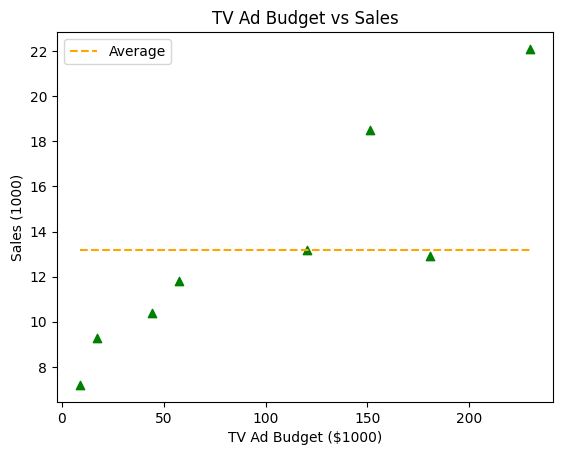

In [1763]:
# Naive model (average)
plt.scatter(TV, y, c="g", marker="^")
plt.plot(x_TV, y_avg, c="orange", linestyle="--", label="Average")

plt.xlabel("TV Ad Budget ($1000)")
plt.ylabel("Sales (1000)")
plt.title("TV Ad Budget vs Sales")
plt.legend()

## Exercise: Simple Data Plotting 
find KNN

In [1764]:
df = advertising
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [1765]:
df_new = df[:7]
df_new

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8


Text(0.5, 1.0, 'TV Ad Budget vs Sales')

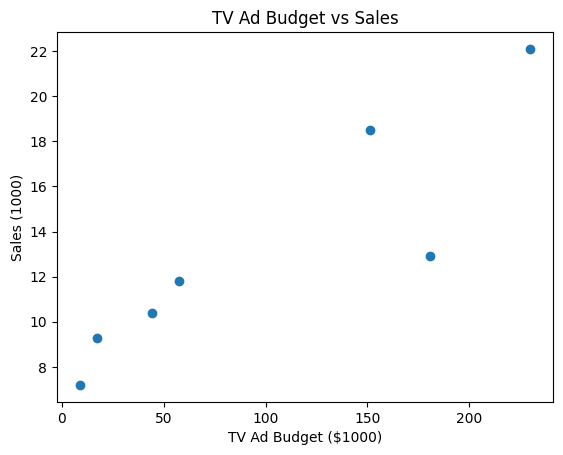

In [1766]:
plt.scatter(df_new.TV, df_new.sales)
plt.xlabel("TV Ad Budget ($1000)")
plt.ylabel("Sales (1000)")
plt.title("TV Ad Budget vs Sales")

## Exercise: Simple kNN Regression



In [1767]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

In [1768]:
df_adv = df
df_adv.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [1769]:
# training data
# x_true = df_adv.TV[5:13]
# y_true = df_adv.sales[5:13]

x_train, x_test, y_train, y_test = train_test_split(
    df_adv.TV, df_adv.sales, train_size=0.6, random_state=42
)  # to compare with sklean at end
# x_train, x_test, y_train, y_test = train_test_split(df_adv.TV, df_adv.sales, train_size=.1,random_state=42) # to compare with sklean at end


# x_true = df_adv.TV
# y_true = df_adv.sales
x_true = x_train  # so i dont have to update code
y_true = y_train  # so i dont have to update code

idx = np.argsort(x_true).values  # cant use sort because need to match x and y
x_true = x_true.iloc[idx].values
y_true = y_true.iloc[idx].values

In [1770]:
def find_nearest_neighbor(array, value):
    idx = pd.Series(np.abs(array - value)).idxmin()

    return idx, array[idx]

In [1771]:
def find_nearest_neighbor_with_k(array, value, k):
    nearness = pd.Series(np.abs(array - value))
    nearness_idx = list(enumerate(nearness))  # add idxs
    NNs = sorted(nearness_idx, key=lambda x: x[1])[:k]

    return NNs

In [1772]:
# sim x
x = np.linspace(x_true.min(), x_true.max(), 100)
# x = np.linspace(x_true.min(), x_true.max())
# y = np.zeros(len(x))

In [1773]:
# for i, xi in enumerate(x):
#     y[i] = y_true[find_nearest_neighbor(x_true, xi)[0]]


def get_model_y_vals(k):
    y = np.zeros(len(x))

    for i, xi in enumerate(x):
        NNs = find_nearest_neighbor_with_k(x_true, xi, k)
        NNs_idx = [nn[0] for nn in NNs]
        NNs_y_vals = [y_true[idx] for idx in NNs_idx]

        y[i] = np.mean(NNs_y_vals)

    return y


# get_model_y_vals(1)

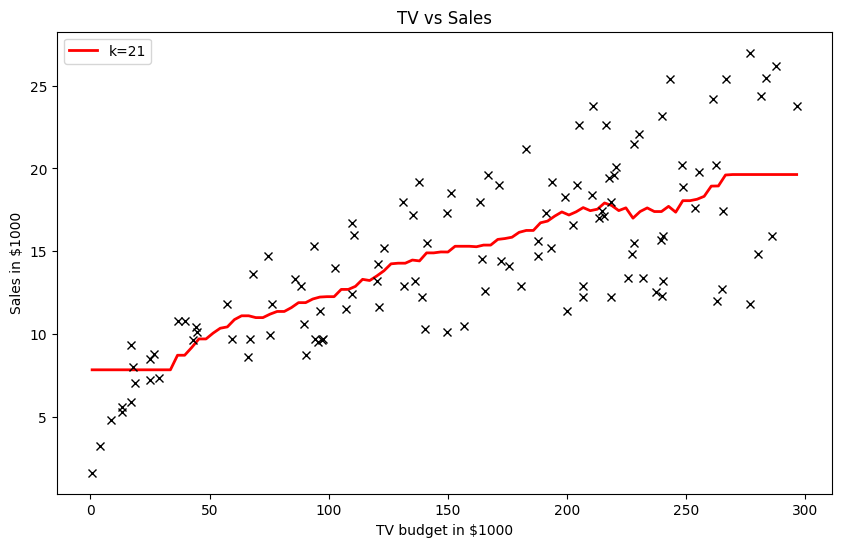

In [1774]:
plt.subplots(figsize=(10, 6))

# plt.plot(x, get_model_y_vals(1), "-", color="grey", label="k=1", linewidth=2)
# plt.plot(x, get_model_y_vals(2), "g-.", label="k=2", linewidth=2)
# plt.plot(x, get_model_y_vals(3), "r-.", label="k=3", linewidth=2)
# plt.plot(x, get_model_y_vals(5), "g-", label="k=5", linewidth=2)
# plt.plot(x, get_model_y_vals(7), "y-.", label="k=7", linewidth=2)
# plt.plot(x, get_model_y_vals(10), "r-", label="k=10", linewidth=2)
plt.plot(x, get_model_y_vals(21), "r-", label="k=21", linewidth=2)
# plt.plot(x, get_model_y_vals(70), "b-", label="k=70", linewidth=2)
plt.plot(x_true, y_true, "kx")

plt.title("TV vs Sales")
plt.xlabel("TV budget in $1000")
plt.ylabel("Sales in $1000")

plt.legend()

### with sklearn now

In [1775]:
x = df[["TV"]].values
y = df["sales"].values
y[:5]

array([22.1, 10.4,  9.3, 18.5, 12.9])

In [1776]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.6, random_state=42
)

# next lesson switches seeds
# x_train, x_test, y_train, y_test = train_test_split(
#     x, y, train_size=0.6, random_state=66
# )

In [1777]:
k_value_min = 1
k_value_max = 70
k_list = np.linspace(k_value_min, k_value_max, 70)

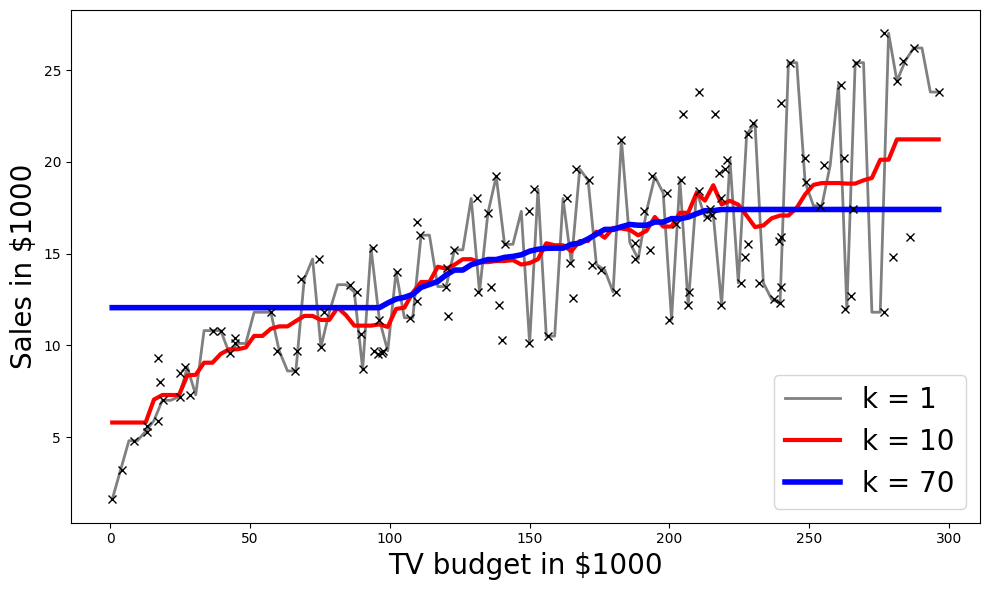

In [1778]:
# Set the grid to plot the values
fig, ax = plt.subplots(figsize=(10, 6))

# Variable used to alter the linewidth of each plot
j = 0

# Loop over all the k values
for k_value in k_list:

    # Creating a kNN Regression model
    model = KNeighborsRegressor(n_neighbors=int(k_value))

    # Fitting the regression model on the training data
    model.fit(x_train, y_train)

    # Use the trained model to predict on the test data
    y_pred = model.predict(x_test)

    # Helper code to plot the data along with the model predictions
    colors = ["grey", "r", "b"]
    if k_value in [1, 10, 70]:
        xvals = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
        ypreds = model.predict(xvals)
        ax.plot(
            xvals,
            ypreds,
            "-",
            label=f"k = {int(k_value)}",
            linewidth=j + 2,
            color=colors[j],
        )
        j += 1

ax.legend(loc="lower right", fontsize=20)
ax.plot(x_train, y_train, "x", label="train", color="k")
ax.set_xlabel("TV budget in $1000", fontsize=20)
ax.set_ylabel("Sales in $1000", fontsize=20)
plt.tight_layout()

## Now plot k vs MSE to find best k value 
also can get R-squared of best

21

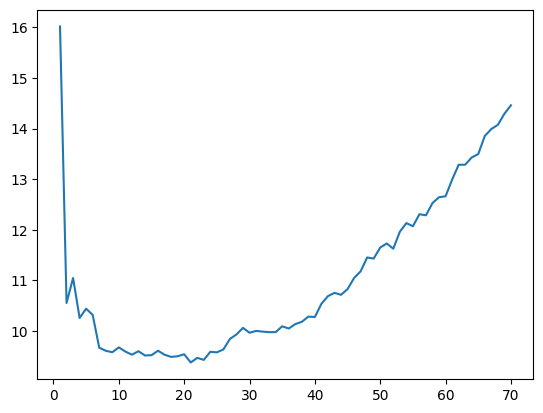

In [ ]:
x_sim = np.linspace(1, 70, 70)

# Loop over all the k values
err_vals = []

for k_value in range(70):
    k_value += 1  # no zero k val allowed

    model = KNeighborsRegressor(n_neighbors=k_value)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    err_vals.append(np.mean((y_pred - y_test) ** 2))


plt.plot(x_sim, err_vals)
min_index = err_vals.index(min(err_vals))

# see best k
best_k = int(min_index) + 1  # indexing
best_k

In [ ]:
# R-squared of best

model = KNeighborsRegressor(best_k)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
err_val = np.mean((y_pred - y_test) ** 2)

naive_err_val = np.mean((y_train.mean() - y_test) ** 2)

R_squared = 1 - err_val / naive_err_val
R_squared

0.6620596401864066

### following along with lesson excercise


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

In [1782]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [1783]:
x = df[["TV"]].values
y = df["sales"].values

In [ ]:
# diff seed
x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.6, random_state=66
)

In [ ]:
k_value_min = 1
k_value_max = 70

k_list = np.linspace(k_value_min, k_value_max, num=70, dtype=int)

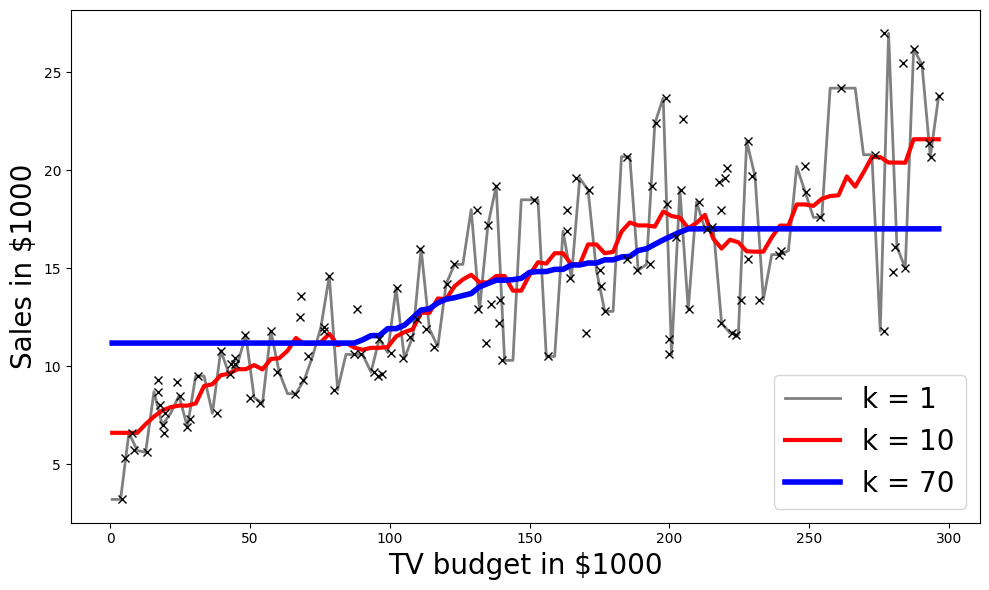

In [ ]:
# Setup a grid for plotting the data and predictions
fig, ax = plt.subplots(figsize=(10, 6))

# Create a dictionary to store the k value against MSE fit {k: MSE@k}
knn_dict = {}

# Variable used for altering the linewidth of values kNN models
j = 0

# Loop over all k values
for k_value in k_list:

    # Create a KNN Regression model for the current k
    model = KNeighborsRegressor(n_neighbors=int(k_value))

    # Fit the model on the train data
    model.fit(x_train, y_train)

    # Use the trained model to predict on the test data
    y_pred = model.predict(x_test)

    # Calculate the MSE of the test data predictions
    MSE = mean_squared_error(y_test, y_pred)

    # Store the MSE values of each k value in the dictionary
    knn_dict[k_value] = MSE

    # Helper code to plot the data and various kNN model predictions
    colors = ["grey", "r", "b"]
    if k_value in [1, 10, 70]:
        xvals = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
        ypreds = model.predict(xvals)
        ax.plot(
            xvals,
            ypreds,
            "-",
            label=f"k = {int(k_value)}",
            linewidth=j + 2,
            color=colors[j],
        )
        j += 1

ax.legend(loc="lower right", fontsize=20)
ax.plot(x_train, y_train, "x", label="test", color="k")
ax.set_xlabel("TV budget in $1000", fontsize=20)
ax.set_ylabel("Sales in $1000", fontsize=20)
plt.tight_layout()

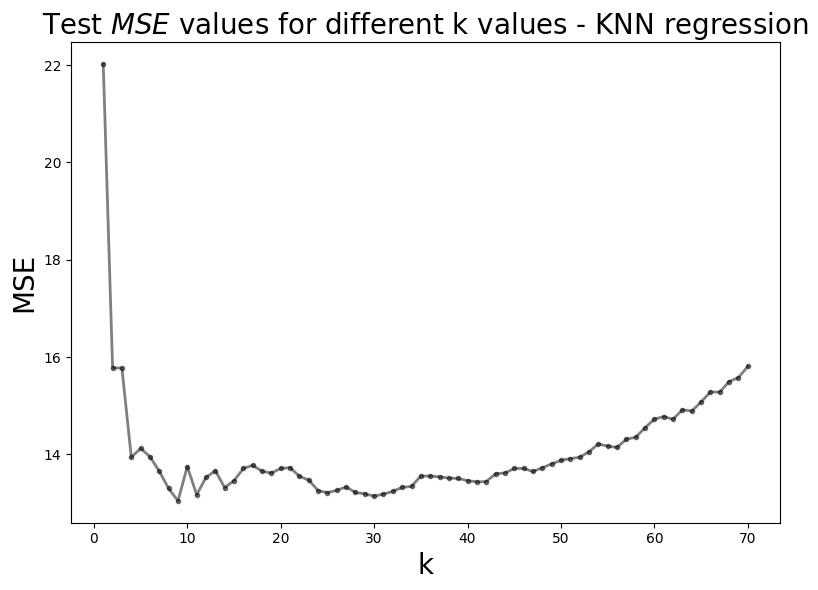

In [ ]:
# Plot a graph which depicts the relation between the k values and MSE
plt.figure(figsize=(8, 6))
plt.plot(knn_dict.keys(), knn_dict.values(), "k.-", alpha=0.5, linewidth=2)

# Set the title and axis labels
plt.xlabel("k", fontsize=20)
plt.ylabel("MSE", fontsize=20)
plt.title("Test $MSE$ values for different k values - KNN regression", fontsize=20)
plt.tight_layout()

In [ ]:
### edTest(test_mse) ###

# Find the lowest MSE among all the kNN models
min_mse = min(knn_dict.values())

# Use list comprehensions to find the k value associated with the lowest MSE
best_model = [key for (key, value) in knn_dict.items() if value == min_mse]

# Print the best k-value
print("The best k value is ", best_model, "with a MSE of ", min_mse)

The best k value is  [9] with a MSE of  13.046766975308643


In [ ]:
# Helper code to compute the R2_score of your best model
model = KNeighborsRegressor(n_neighbors=best_model[0])
model.fit(x_train, y_train)
y_pred_test = model.predict(x_test)

# Print the R2 score of the model
print(f"The R2 score for your model is {r2_score(y_test, y_pred_test)}")

The R2 score for your model is 0.5492457002030715
